In [1]:
!pip install -q -U transformers accelerate requests

import os
import json
import glob
import random
import torch
import torch.nn.functional as F
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoProcessor, LlavaForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 93.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32

In [2]:
MODEL_NAME = "llava-hf/llava-1.5-7b-hf"

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    max_memory={0: "12GiB", 1: "12GiB"},
)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

ln_f = model.model.language_model.norm
lm_head = model.lm_head

n_layer = model.config.text_config.num_hidden_layers
hidden_dim = model.config.text_config.hidden_size
print(n_layer, "language model layers,", hidden_dim, "hidden dim")

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

32 language model layers, 4096 hidden dim


In [3]:
_encoder_cache = {}

def _vision_tower_hook(module, inputs, output):
    # output.last_hidden_state: (1, 577, 1024) for CLIP-ViT-L/14-336.
    # Position 0 is the CLS token, dropping it
    _encoder_cache["patch_embeddings"] = output.last_hidden_state[:, 1:, :].detach().cpu()

_hook_handle = model.model.vision_tower.register_forward_hook(_vision_tower_hook)
print("hook registered on model.vision_tower")

hook registered on model.vision_tower


images live in: /kaggle/input/datasets/nadaibrahim/coco2014/val2014/val2014
batch 5: 70 images


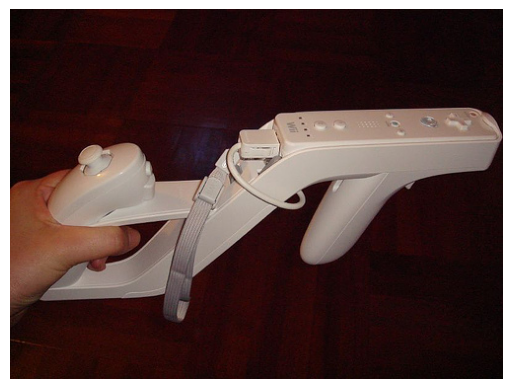

In [4]:
COCO_ROOT = "/kaggle/input/datasets/nadaibrahim/coco2014"
CACHE_DIR = "/kaggle/working/cache/hidden_states"
os.makedirs(CACHE_DIR, exist_ok=True)

random.seed(42)


img_dir = "/kaggle/input/datasets/nadaibrahim/coco2014/val2014/val2014"
print("images live in:", img_dir)

all_images = sorted(glob.glob(os.path.join(img_dir, "COCO_val2014_*.jpg")))
assert len(all_images) > 0, f"no COCO_val2014_*.jpg files found in {img_dir}"

random.seed(42)
all_images_shuffled = all_images.copy()
random.shuffle(all_images_shuffled)

BATCH_INDEX = 5
BATCH_SIZE = 70

IMAGE_PATHS = all_images_shuffled[BATCH_INDEX * BATCH_SIZE : (BATCH_INDEX + 1) * BATCH_SIZE]
print(f"batch {BATCH_INDEX}: {len(IMAGE_PATHS)} images")

CAPTION_PROMPT = "Describe this image in detail."
CAPTION_MAX_NEW_TOKENS = 100


def load_image(path):
    return Image.open(path).convert("RGB")


def build_inputs(image, text=CAPTION_PROMPT):
    conversation = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": text}]}]
    prompt_text = processor.apply_chat_template(conversation, add_generation_prompt=True)
    return processor(text=prompt_text, images=image, return_tensors="pt").to(model.device, torch.float16)


preview_image = load_image(IMAGE_PATHS[0])
plt.imshow(preview_image); plt.axis("off"); plt.show()

In [5]:
@torch.no_grad()
def cache_one_image(image_path, image_id):
    """Two-pass caching for one image. Returns a dict ready for torch.save."""
    image = load_image(image_path)
    inputs = build_inputs(image)
    prompt_len = inputs["input_ids"].shape[-1]

    # Pass 1 -- generate a caption
    gen_ids = model.generate(**inputs, max_new_tokens=CAPTION_MAX_NEW_TOKENS, do_sample=False)
    caption_text = processor.tokenizer.decode(gen_ids[0, prompt_len:], skip_special_tokens=True)

    # Pass 2 -- one teacher-forced pass over prompt + generated caption
    _encoder_cache.clear()
    full_attention_mask = torch.ones_like(gen_ids)
    outputs = model(
        input_ids=gen_ids,
        pixel_values=inputs["pixel_values"],
        attention_mask=full_attention_mask,
        output_hidden_states=True,
    )

    # position tagging
    full_len = gen_ids.shape[-1]
    image_token_id = model.config.image_token_index
    image_positions = (gen_ids[0] == image_token_id).nonzero(as_tuple=True)[0]

    all_positions = torch.arange(full_len)
    is_image = torch.zeros(full_len, dtype=torch.bool)
    is_image[image_positions] = True
    is_caption = all_positions >= prompt_len
    # prompt-text positions (the fixed instruction template) are neither -- drop them

    keep_positions = all_positions[is_image | is_caption]
    hidden_states = torch.stack([
        layer[0, keep_positions, :].half().cpu() for layer in outputs.hidden_states
    ])  # (n_layer+1, len(keep_positions), hidden_dim)

    target_probs = F.softmax(outputs.logits[0, keep_positions, :].float(), dim=-1).half().cpu()

    return {
        "image_id": image_id,
        "image_path": image_path,
        "caption_text": caption_text,
        "prompt_len": prompt_len,
        "full_len": full_len,
        "keep_positions": keep_positions,
        "is_image_at_keep": is_image[keep_positions],
        "is_caption_at_keep": is_caption[keep_positions],
        "hidden_states": hidden_states,
        "target_probs": target_probs,
        "encoder_patch_embeddings": _encoder_cache["patch_embeddings"],  # (1, 576, clip_hidden_dim), pre-projector
    }

In [6]:
cache_paths = []
for i, path in enumerate(IMAGE_PATHS):
    image_id = os.path.splitext(os.path.basename(path))[0]
    entry = cache_one_image(path, image_id)

    out_path = os.path.join(CACHE_DIR, f"{image_id}.pt")
    torch.save(entry, out_path)
    cache_paths.append(out_path)

    if i == 0:
        size_mb = os.path.getsize(out_path) / 1e6
        projected_gb = size_mb * len(IMAGE_PATHS) / 1000
        print(f"first image cached -- {size_mb:.1f} MB/image.")
        print(f"at this rate, {len(IMAGE_PATHS)} images will use ~{projected_gb:.1f} GB. ")
    if i % 10 == 0:
        print(f"[{i+1}/{len(IMAGE_PATHS)}] {image_id}: {entry['caption_text']!r}")

print(f"done, {len(cache_paths)} images cached to {CACHE_DIR}")

first image cached -- 214.9 MB/image.
at this rate, 70 images will use ~15.0 GB. 
[1/70] COCO_val2014_000000534533: 'The image features a person holding a Nintendo Wii game controller in their hands. The controller is designed to look like a gun, and it is being held in a way that it appears to be a real gun. The person is standing on a wooden floor, which serves as the background for the scene.'
[11/70] COCO_val2014_000000032965: "The image features a woman standing on a beach, holding two umbrellas in her hands. She is smiling and appears to be enjoying her time at the beach. The umbrellas are positioned above her head, providing shade and protection from the sun.\n\nIn the background, there is a boat visible on the water, adding to the beach atmosphere. The woman's presence and the beach setting create a pleasant and relaxing scene."
[21/70] COCO_val2014_000000462687: 'The image features a group of four people sitting together, enjoying a meal. They are eating pizza, with a couple o

In [7]:
@torch.no_grad()
def logit_lens_from_cache(entry, position_idx, top_k=5):
    n = entry["hidden_states"].shape[0]
    results = []
    for i in range(n):
        h = entry["hidden_states"][i, position_idx, :].to(lm_head.weight.device, torch.float16)
        if i < n - 1:
            h = ln_f(h)
        logits = lm_head(h)
        probs = torch.softmax(logits.float(), dim=-1)
        top_probs, top_ids = probs.topk(top_k)
        results.append([(processor.tokenizer.decode([tid]), float(p)) for tid, p in zip(top_ids.tolist(), top_probs.tolist())])
    return results


for path in cache_paths[:5]:
    entry = torch.load(path)
    last_pos = entry["hidden_states"].shape[1] - 1
    lens_logits = lm_head(entry["hidden_states"][-1, last_pos, :].to(lm_head.weight.device, torch.float16))
    lens_probs = torch.softmax(lens_logits.float(), dim=-1).cpu()
    real_probs = entry["target_probs"][last_pos, :].float()
    max_diff = (lens_probs - real_probs).abs().max().item()
    print(f"{entry['image_id']}: max prob diff vs cached target = {max_diff:.2e}")
    assert max_diff < 3e-2, "logit lens wiring isn't right, check ln_f/lm_head."

COCO_val2014_000000534533: max prob diff vs cached target = 2.22e-04
COCO_val2014_000000069584: max prob diff vs cached target = 4.24e-05
COCO_val2014_000000251370: max prob diff vs cached target = 1.80e-04
COCO_val2014_000000028676: max prob diff vs cached target = 9.75e-05
COCO_val2014_000000054654: max prob diff vs cached target = 1.92e-04


caption: The image features a person holding a Nintendo Wii game controller in their hands. The controller is designed to look like a gun, and it is being held in a way that it appears to be a real gun. The person is standing on a wooden floor, which serves as the background for the scene.


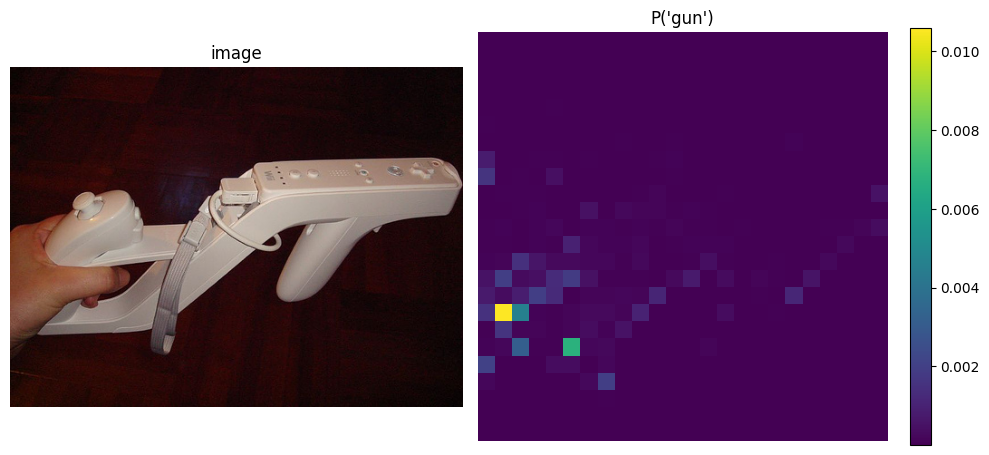

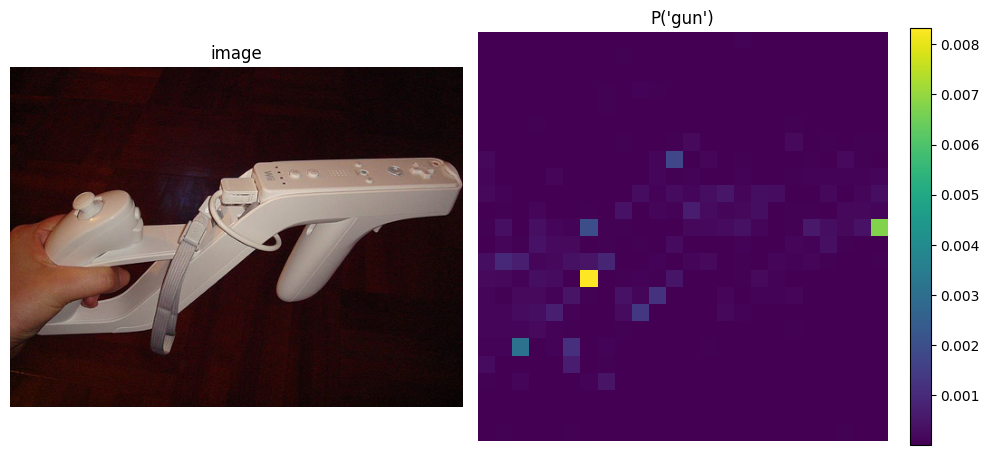

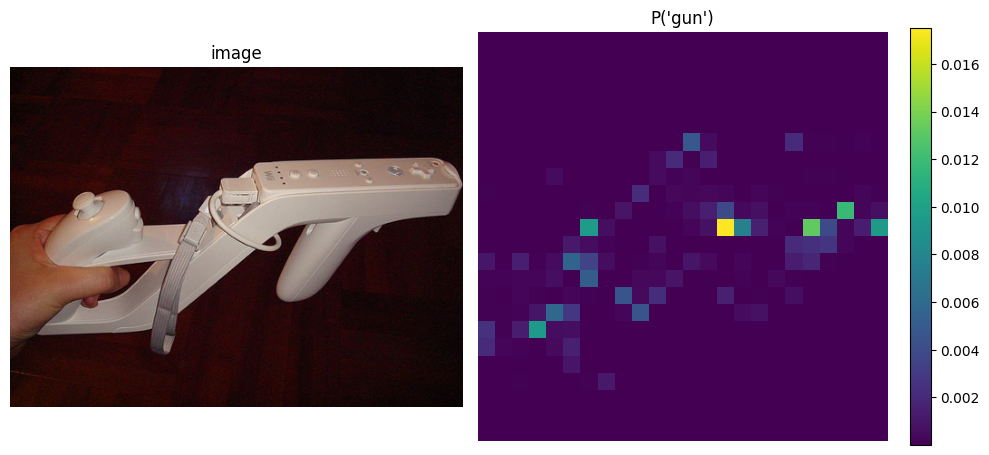

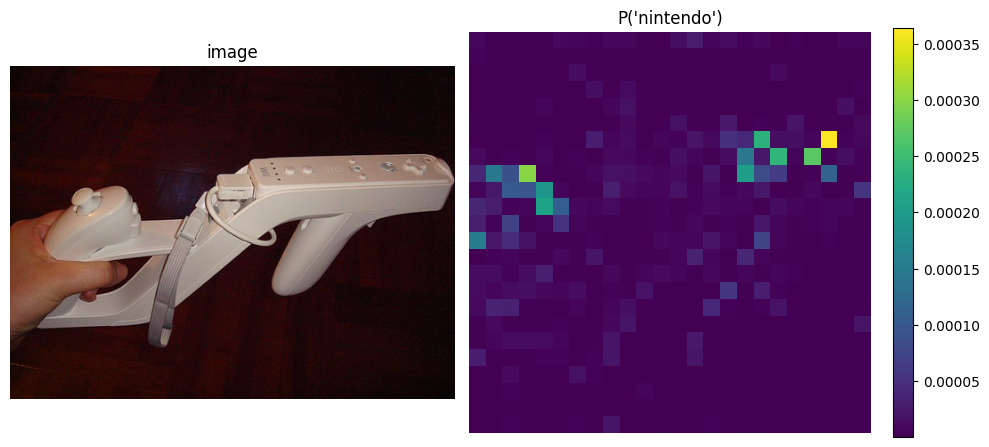

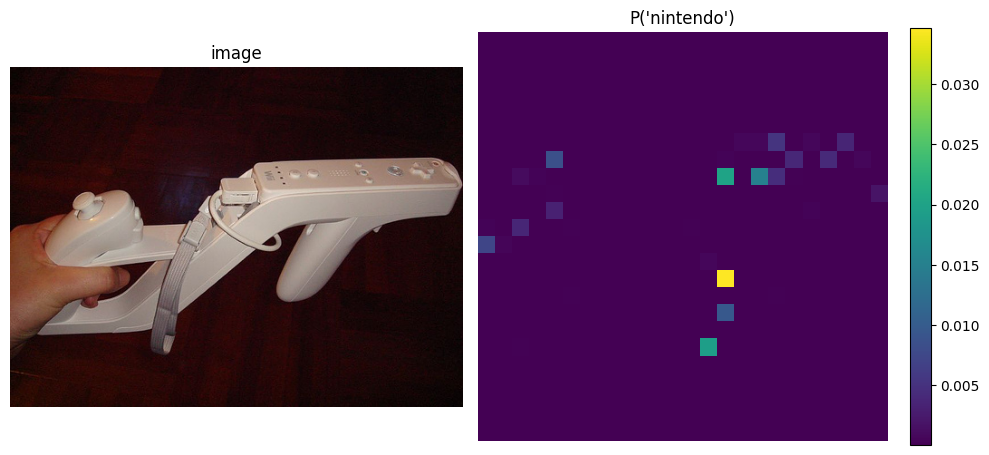

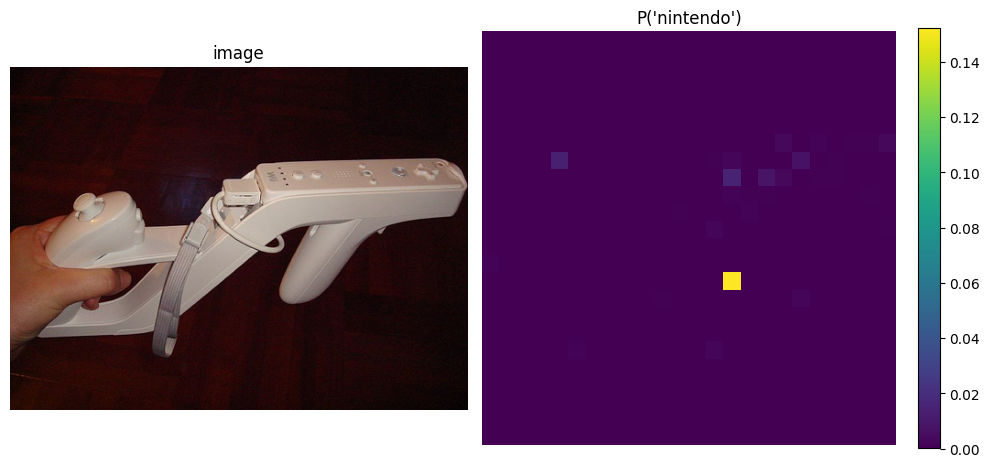

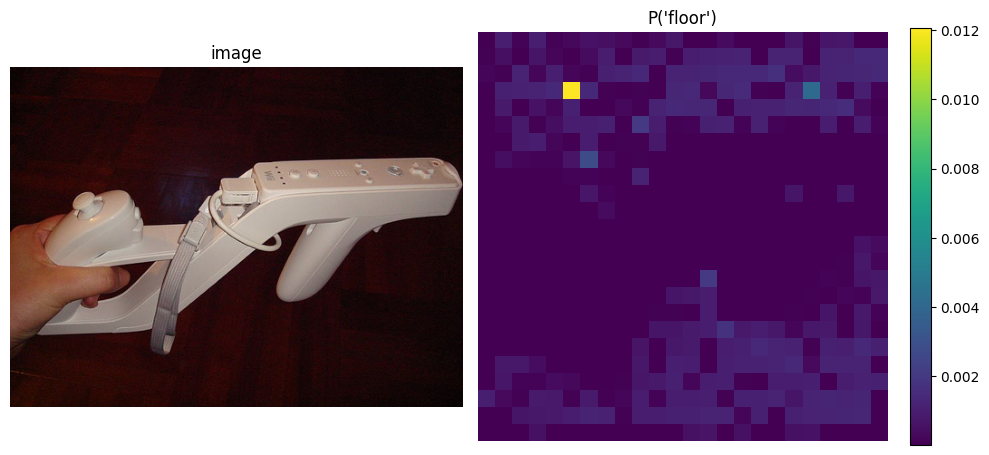

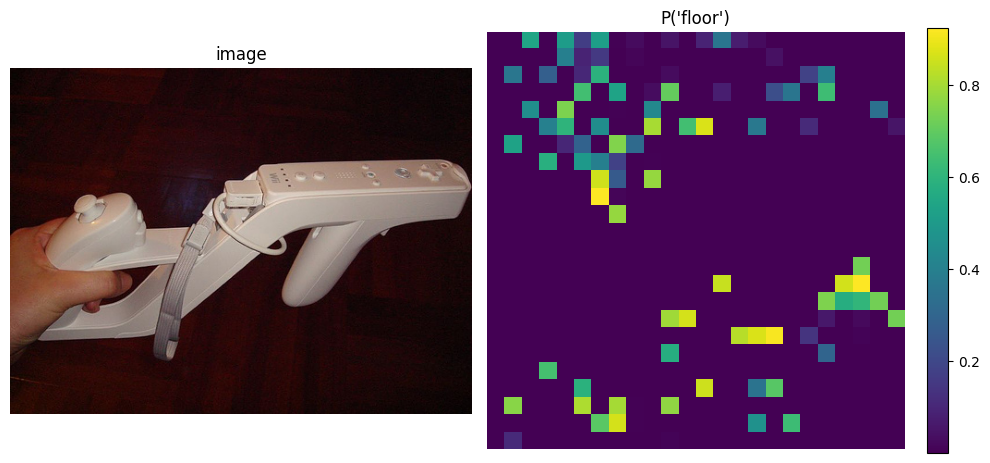

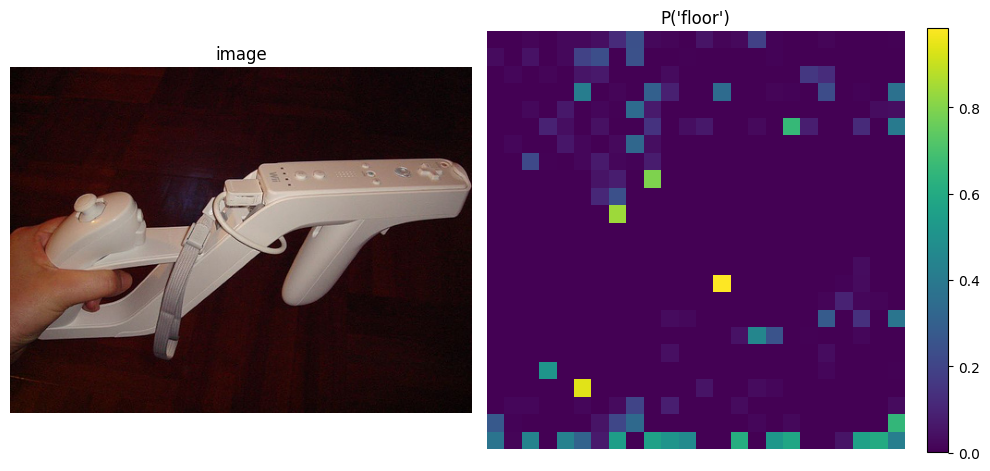

In [8]:
def plot_confidence_heatmap(image, confidence, title=""):
    side = model.config.vision_config.image_size // model.config.vision_config.patch_size
    grid = confidence.reshape(side, side)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image); axes[0].set_title("image"); axes[0].axis("off")
    im = axes[1].imshow(grid, cmap="viridis"); axes[1].set_title(title); axes[1].axis("off")
    fig.colorbar(im, ax=axes[1], fraction=0.046)
    plt.tight_layout(); plt.show()


@torch.no_grad()
def image_token_confidence_from_cache(entry, target_token, layer_idx=-1):
    ids = processor.tokenizer.encode(target_token.strip(), add_special_tokens=False)
    target_id = ids[-1]
    n = entry["hidden_states"].shape[0]
    idx = layer_idx % n
    image_mask = entry["is_image_at_keep"]
    h = entry["hidden_states"][idx, image_mask, :].to(lm_head.weight.device, torch.float16)
    if idx < n - 1:
        h = ln_f(h)
    logits = lm_head(h)
    probs = torch.softmax(logits.float(), dim=-1)
    return probs[:, target_id].cpu()


demo_entry = torch.load(cache_paths[0])
print("caption:", demo_entry["caption_text"])
demo_image = load_image(demo_entry["image_path"])
for word in [" gun", " nintendo", " floor"]:
    for layer in [10, 20, 25]:
        conf = image_token_confidence_from_cache(demo_entry, word, layer_idx=layer)
        plot_confidence_heatmap(demo_image, conf.numpy(), title=f"P({word.strip()!r})")